  \\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\ 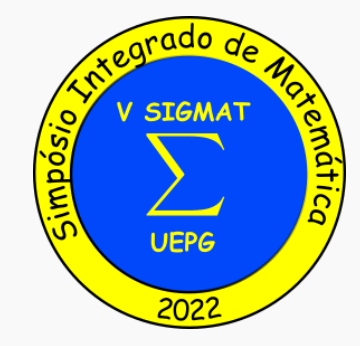 

#<font color='blue'> Processamento de linguagem natural em ciência de dados: Uma aplicação da decomposição em valores singulares de matrizes à classificação de textos 


**Material produzido por Brayan Mauricio Rodríguez Garzón**

**Departamento de matemática e estatística UEPG**



## Descrição do problema





Propomos neste minicurso, analisar a similaridade entre as falas presentes nos vídeos de dois canais de YouTube de divulgação de ciência:

Nerdologia:

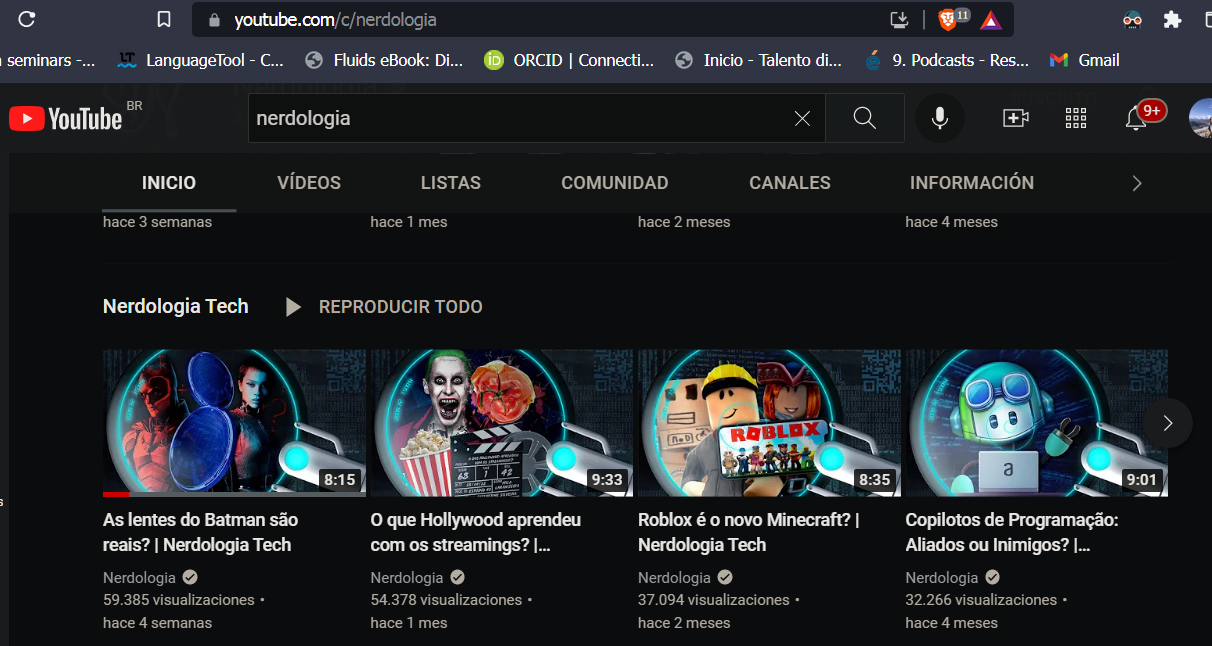

Ciência todo día

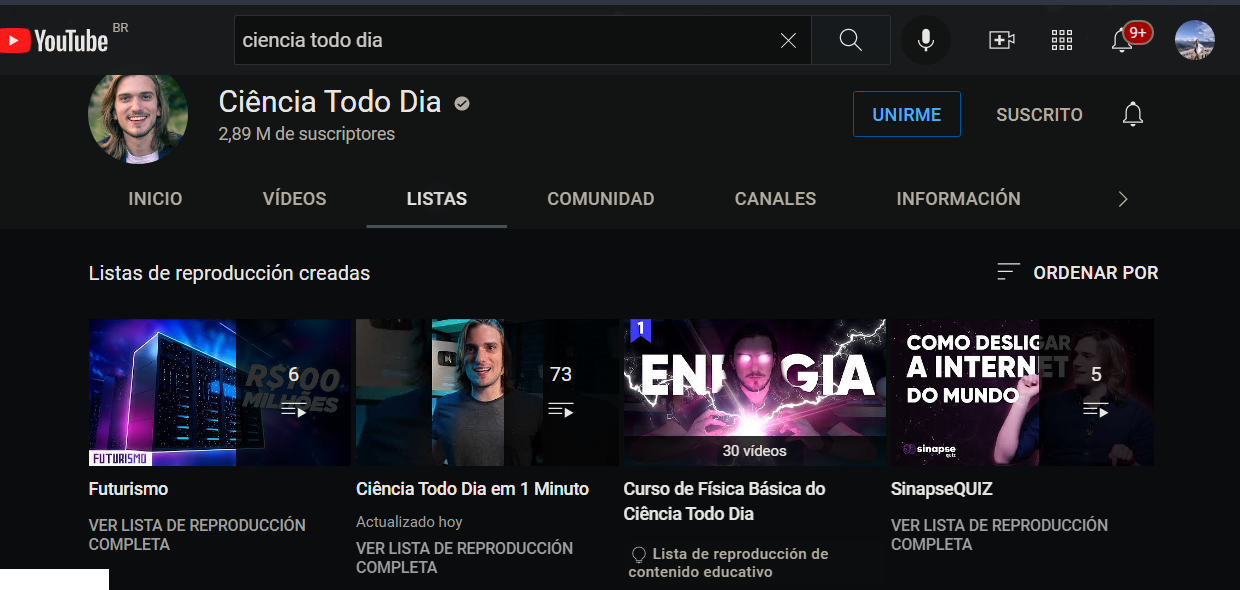



### Obtenção e tratamento dos cados

#### Coleta ddos dados

Coletamos as lendas de 11 vídeos de cada canal, estas lendas são geradas automaticamente pelos algorítmicos de reconhecimento de voz do YouTube.

Cada uma das falas foi guardada em um arquivo.txt codificado no formato uft-8.

#### Tratamento dos dados 

Com a finalidade de medir a similaridade entre os textos, precisamos associar com os textos alguma descrição matemática que nos permita calcular distância entre textos, existem diversas propostas para fazer isto:

- Medidas de resumo;
- Frequências;
- Vectorização.

Vamos  vetorizar os textos, o jeito que vamos usar para vetorizar, falando a grosso modo vetorizar um texto é associar um vetor com cada texto, onde cada entrada de este vetor, represente informação relevante do texto.


No  nosso enfoque, vamos escolher como entrada de um determinado vetor, representante de um texto, as diferentes palavras  no texto, assim textos que usem palavras similares e com frequências parecidas se espera que sejam similares entre si.

Os textos de nosso exemplo são as falas de vídeos, **é claro que vídeos tem muitas outras propriedades**, como os efeitos visuais, animações e uso de imagens, nosso objetivo, será tentar entender até que ponto somente a fala do vídeo serve definir sua similaridade com outros vídeos.







## Processamento dos textos

Primeiramente vamos a carregar os textos ao ambiente virtual Google Colab.

Temos que conseguir ler os textos, para isto usamos


In [51]:
texto=open('/content/CT01.txt','r')
#print(texto.read())

Em aplicações podemos estar interessados em analisar miles de textos, por exemplo, analisar os comentários em Twitter.


Por este motivo, precisamos alguma forma de ler sequencialmente todos os textos e extrair características.



In [52]:
#import cv2
import glob
import os


path = "/content/*.*" # A pasta que contém os arquivos

files = glob.glob("/content/*")  # O diretório contém um conjunto dos nomes
                            #documentos já no formato ASCII
print(files[:5])# Imprime os primeiros 5

files = [f for f in files if os.path.isfile(f)]



['/content/ND09.txt', '/content/CT03.txt', '/content/CT04.txt', '/content/CT01.txt', '/content/CT11.txt']


Temos uma lista com o nome de todos os arquivos, a última linha é para garantir que somente arquivos sejam salvos.

Vamos juntar todos os textos num arquivo, visando processar toda a diversidade de palavras que aparecem em todos os textos

In [53]:
docs = ''
for fname in files:
    with open(fname,'r') as f:
        docs = docs+' '+f.read()  # todos os documentos
                                  # são concatenadas na string 'docs'


In [54]:
len(docs)

247599

#### Tokenize

Chama-se de token qualquer reunião de caracteres ASCII, por exemplo: casa, %¨#$as, #tag.

Para guardar separadamente todos os tokens, precisamos percorrer todas as palavras da string ddocs e ir armazenando as novas palavras numa lista, isto pode ser feito de diversas maneiras, nos aplicaremos um método do pacote `nltk `(Natural Language Toolkit [link](https://www.nltk.org/api/nltk.html)) chamado `tokenize`

In [55]:
# nltk.word_tokenize transforma a string em uma lista de palavras
import nltk
nltk.download('punkt')

words = nltk.word_tokenize(docs) # extrai as palavras
print(words[:20])    # 20 primeiras palavras extraidas

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['\ufeffe', 'por', 'quê', 'que', 'é', 'seu', 'solta', 'duas', 'bolinhas', 'juntas', 'eu', 'não', 'posso', 'ter', 'apenas', 'uma', 'bolinha', 'saindo', 'do', 'outro']


*Tokens* compostos por caracteres diferentes dos alfanuméricos, não são muito informativos na linguagem natural, vamos descartar eles:

In [56]:
import string
# removend todos os simbolos da lista de palavras
# o método "isalpha" retorna True quando a string é 
# formada apenas por letras do alphabeto
# string.ascii_letters contém a lista de todas as letras do alphabeto

# remove simbolos da
# lista de palavras
words = [w.lower() for w in words if w.isalpha() and w not in string.ascii_letters]  

print(words[:20])

['por', 'quê', 'que', 'é', 'seu', 'solta', 'duas', 'bolinhas', 'juntas', 'eu', 'não', 'posso', 'ter', 'apenas', 'uma', 'bolinha', 'saindo', 'do', 'outro', 'lado']


#### Stopwords

Existem palavras que são comuns a qualquer texto, pois são palavras necessárias gramaticalmente, por exemplo, os pronomes, ou os árticos:

- ele,ela,eu,...
- a,o, ou, ...

Estas palavras existem e tem sentido semântico, porem não carregam muita informação, pois são palavras que permitem a construção dos textos. Porem, como nosso alvo é avaliar a similaridade entre textos baseados na informação que eles contêm, nos eliminamos estes blocos de construção da linguagem, que não contém muita informação.


Esta categoria de palavras são conhecidas como ***stopwords***, listas de stopwords para cada língua foi construída voluntariamente pela comunidade de desenvolvedores dos algorítimos de processamento de linguagem natural, nos faremos o download de stopwords para a língua portuguesa.


In [57]:
from nltk.corpus import stopwords # conjunto de dados
nltk.download('stopwords')

# lista das stop words
stop_words = stopwords.words('portuguese')
print(stop_words[:5])

words = [w for w in words if w not in stop_words] # removendo palavras irrelevantes da lista
print('Palavras Relevantes\n',words[:20])    

['de', 'a', 'o', 'que', 'e']
Palavras Relevantes
 ['quê', 'solta', 'duas', 'bolinhas', 'juntas', 'posso', 'ter', 'apenas', 'bolinha', 'saindo', 'outro', 'lado', 'dobro', 'velocidade', 'aí', 'pessoal', 'nome', 'pedro', 'luz', 'curso']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Normalização Léxica

Nas palavras usadas em línguas, tem muitas variações de um mesmo significado, mas que constituem palavras diferentes, exemplo de isto pode ser a conjugação de um verbo, ou o tempo em que é estruturada uma oração (passado, presente, futuro)

- Andar, andarei, andaremos.

Pode ser encontrada mais informação  [aqui](https://www.datacamp.com/community/tutorials/text-analytics-beginners-nltk)



In [58]:
from nltk.stem import PorterStemmer

words = [PorterStemmer().stem(w) for w in words]
print(words[:100])

['quê', 'solta', 'dua', 'bolinha', 'junta', 'posso', 'ter', 'apena', 'bolinha', 'saindo', 'outro', 'lado', 'dobro', 'velocidad', 'aí', 'pessoal', 'nome', 'pedro', 'luz', 'curso', 'física', 'básica', 'ciência', 'todo', 'dia', 'bom', 'então', 'pensando', 'conservação', 'momento', 'problema', 'nenhum', 'concorda', 'gent', 'consegu', 'momento', 'tudo', 'certo', 'ant', 'dua', 'bolinha', 'massa', 'velocidad', 'ver', 'dá', 'valor', 'massa', 'bolinha', 'movendo', 'velocidad', 'ver', 'acontec', 'sempr', 'saem', 'dua', 'bolinha', 'mesma', 'velocidad', 'outro', 'lado', 'bom', 'entend', 'pergunta', 'precisamo', 'entrar', 'pouco', 'história', 'senhorita', 'emili', 'chá', 'turnê', 'podemo', 'considerar', 'maior', 'cientista', 'francesa', 'existiram', 'aí', 'vamo', 'entend', 'ideia', 'trá', 'conceito', 'energia', 'trabalho', 'vamo', 'discutir', 'fundo', 'capítulo', 'termodinâmica', 'emili', 'chato', 'lei', 'altura', 'contemporânea', 'newton', 'muita', 'competência', 'área', 'física']


Outras limpezas poderiam ser feitas, segundo o entendimento do pesquisador sobre o objeto de estudo:

- Palavras longas demais e pouco frequentes;
- Expressões de duas ou três palavras.


In [59]:
import numpy as np
import pandas as pd
import seaborn as sns


### Construindo a Matriz Documentos $\times$ Palavras

A construção de uma "Bag of Words" (matrix Documentos $\times$ Palavras) é feita aplicando todos os passos acima em cada documento, juntando todas as informações em um DataFrame (ou array) onde as linhas representam os documentos e as colunas o conjunto de palavras. Cada entrada $(i,j)$ do DataFrame representa o número de vezes que a palavra $j$ aparece no documento $i$, ou seja:


$$
\begin{array}{c}\\
Tex_1\\
Tex_2\\
\vdots\\
Tex_n
\end{array}
\quad\Longrightarrow\quad
\begin{array}{lcccc}
     & palavra_1 & palavra_2 & \cdots & palavra_m\\
Text_1 & 0 & 2 &  & 0\\ 
Text_2 & 3 & 0 &  & 1\\
      &   &   & \vdots & \\
Text_n & 0 & 0 &  & 0\\     
\end{array}
$$

Percorremos todas as etapas num bloco de código, e adicionando uma última etapa que conta quantas vezes aparece uma palavra num determinado texto.

In [60]:
 # constuindo um dicionario onde a chave é o rótulo do documento e o valor 
# as palavras que ocorrem no documento
import glob
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter

# lista das stop words
stop_words = stopwords.words('portuguese')

files = glob.glob("/content/*")  # vamos utilizar os documento que estão no diretório DocCol3 
files = [f for f in files if os.path.isfile(f)]
ddocs = {}
for fname in files:
    key = fname.split('/')[-1][:4]  # rotulo do documento
    with open(fname,'r') as f:  # obtendo a lista de palavras processadas de cada documento
        doc = f.read()
        # obtendo palavras do documento
        words = nltk.word_tokenize(doc) 
        # removendo simbolos
        words = [w.lower() for w in words if w.isalpha()] 
        # removendo stop words
        words = [w for w in words if w not in stop_words]
        # stemming
        words = [PorterStemmer().stem(w) for w in words]
        # calculando a frequência de palavras
        ddocs[key] = dict(Counter(words))
      
print(list(ddocs.keys())[0],'-->',ddocs[list(ddocs.keys())[0]])

ND09 --> {'quê': 1, 'solta': 3, 'dua': 9, 'bolinha': 18, 'junta': 2, 'posso': 1, 'ter': 3, 'apena': 3, 'saindo': 3, 'outro': 8, 'lado': 6, 'dobro': 4, 'velocidad': 18, 'aí': 3, 'pessoal': 1, 'nome': 3, 'pedro': 1, 'luz': 1, 'curso': 5, 'física': 6, 'básica': 1, 'ciência': 2, 'todo': 3, 'dia': 1, 'bom': 3, 'então': 12, 'pensando': 2, 'conservação': 3, 'momento': 5, 'problema': 1, 'nenhum': 1, 'concorda': 1, 'gent': 8, 'consegu': 1, 'tudo': 3, 'certo': 1, 'ant': 3, 'massa': 7, 'm': 2, 'ver': 4, 'dá': 3, 'valor': 1, 'movendo': 1, 'acontec': 3, 'sempr': 2, 'saem': 1, 'mesma': 2, 'entend': 3, 'pergunta': 2, 'precisamo': 4, 'entrar': 1, 'pouco': 2, 'história': 3, 'senhorita': 1, 'emili': 6, 'chá': 1, 'turnê': 1, 'podemo': 4, 'considerar': 1, 'maior': 4, 'cientista': 5, 'francesa': 2, 'existiram': 1, 'vamo': 5, 'ideia': 7, 'trá': 1, 'conceito': 1, 'energia': 43, 'trabalho': 17, 'discutir': 1, 'fundo': 1, 'capítulo': 5, 'termodinâmica': 1, 'chato': 1, 'lei': 1, 'altura': 4, 'contemporânea': 1,

Como a colunas da matriz que queremos construir são todas as palavras que aparecem em todos os documentos, temos que armazenar todas as palavras numa lista

In [61]:
# constrindo a lista de todas as palavras
# precisamos desta lista para definir as colunas do DataFrame Documentos X Palavras
corpus = []

for v in ddocs.values():
    corpus.extend(list(v.keys()))  # juntando as listas de 
                                   # palavras de cada documento
    
corpus = list(set(corpus)) # removendo palavras repetidas
print(corpus[:10])

['bubônica', 'portador', 'fechada', 'alguma', 'óbvio', 'redesenhado', 'coloc', 'demo', 'pessoal', 'ativar']


*Vamos* criar a matriz $Documento \times palavras$, nesta matriz cada linha pode ser visto como um vetor de dimensão dada pela quantidade de palavras diferentes presentes em todos os textos.


In [62]:
# construindo um DataFrame onde os rótulos das colunas são
# as palavras e os das linhas os documentos
import pandas as pd
import numpy as np

rows = list(ddocs.keys())

BoW = pd.DataFrame(data=np.zeros((len(rows),len(corpus))),
                   columns=corpus,index=rows,dtype=int)

for k in ddocs.keys():
    BoW.loc[k,list(ddocs[k].keys())] = list(ddocs[k].values())

BoW.head()  

#BoW.to_csv('bag_of_words.csv')

,bubônica,portador,fechada,alguma,óbvio,redesenhado,coloc,demo,pessoal,ativar,...,estudo,cantada,conflito,complexidad,espaço,direita,adianta,escurec,formam,estaca
ND09,0,0,0,2,0,0,1,0,1,1,...,1,0,1,0,0,0,0,0,0,0
CT03,0,0,0,2,2,0,0,0,1,0,...,1,0,0,0,4,2,0,0,1,0
CT04,0,0,0,2,0,0,0,1,1,0,...,0,0,0,0,2,0,0,0,0,0
CT01,0,0,0,1,0,0,0,0,0,0,...,5,1,0,0,0,0,0,0,0,0
CT11,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,3,0,0,0,2,0


In [63]:
frequency = BoW.sum(axis=0) # conta o número de vezes que cada palavra aparece no corpus
smaller = 1.0               # palavras que aparecem "smaller" ou menos vezes serão removidas
larger = 0.7*BoW.shape[0]   # palavras que aparecem "larger" ou mais vezes serão removidas

s_mask = (frequency <= smaller) | (frequency >= larger)  # mascara boleana indicando as palavras
words_to_remove = frequency[s_mask].index.values         # que serão removidas

m = BoW.shape[1]
BoW = BoW.drop(words_to_remove, axis=1)  # remove as colunas do DataFrame correspondentes 
                                         # as palavras que devem ser removidas
print('Foram removidas',m-BoW.shape[1],'palavras')

Foram removidas 2862 palavras


In [64]:
BoW.shape

(22, 2206)

Finalmente temos todos os textos vetorizados, e poderiamos definir a similaridade entre eles baseandonos nas diferentes distâncias que podem ser definidas sobre os espaços Euclidianos, por exemplo:

Sejam $\mathbb{u}=(x_1,x_2,\ldots ,x_n)$ and $\mathbb{v}=(y_1,y_2,\ldots,y_n)$, então temos


$$||\mathbb{u}-\mathbb{v}||_{L^2}= \sqrt{\sum_{i=1}^{n} (x_i -y_i)^2},$$

ou

$$||\mathbb{u}-\mathbb{v}||_{L^1}=\sum_{i=1}^{n}|x_i-y_i|,$$

ou ainda

$$||\mathbb{u}-\mathbb{v}||_{L^{\infty}}=\max_{1 \leq i \leq \infty} |x_i-y_i|$$







A escolha depende do problema que esteja sendo trabalhado, neste caso em particular que uma boa escolha seria a distância euclidiana, que considera todas as componentes.

Sobre a tabela BoW não podemos fazer operações vetoriais, pois pelo computador ela é considerado outro tipo de objeto, para transformar ela em uma matriz simplesmente salvamos os valores dela:

In [65]:
X = BoW.values

Assim por exemplo para considerar a primeira linha que é o vetor que representa o primeiro texto, criamos o vetor:

In [66]:
v=X[0,:]
v

array([0, 0, 1, ..., 0, 0, 0])

In [67]:
nomes=list(BoW.index)

In [69]:
for i in np.arange(BoW.shape[0]):
  exec(f'v{i}=X[i,:]')


In [70]:
len(v2)

2206

In [71]:
dic_nomes={}

for i in range(BoW.shape[0]):
  dic_nomes[BoW.index[i]]=f'v{i}'

In [72]:
def Distancia_euclidiana(u,v):
  sum=0
  for i in range(BoW.shape[1]):
    sum+=(u[i]-v[i])**2
  d=np.sqrt(sum)
  return(d)


In [73]:
Distancia_euclidiana(v1,v3)

57.844619455918284

In [74]:
dic_nomes['CT01']

'v3'

Calculando o texto mas próximo  de um texto dado, pela distância Euclidiana obtemos 

In [75]:
from numpy.ma.core import argsort
def Texto_mais_proximou(u):
  # vec_consul=dic_nomes[u]
  # print(vec_consul)
  distancias=np.zeros(BoW.shape[0])
  for i in range(BoW.shape[0]):
    # print(f'v{i}')
    distancias[i]=Distancia_euclidiana(u,X[i,:])
  return argsort(distancias)
  

In [76]:
resultados=Texto_mais_proximou(v7)
resultados

array([ 7,  2, 17,  6, 14, 12, 19,  0, 13, 16, 11, 21, 10,  8, 15, 20,  4,
        5,  9,  3,  1, 18])

In [85]:
#dic_nomes

## Análise de componentes principais




Os vetores neste problemas são de difícil visualização, já que são vetores no  espaço $\mathbb{R}^{2206}$, seria muito conveniente, reduzir essa dimensão para $\mathbb{R}^2$ ou $\mathbb{R}^3$, mas preservando ainda a maior quantidade de informação semântica possível.

Como podemos fazer isto?




In [77]:
BoW.shape

(22, 2206)

####Matriz de covarianza

Reduzir $2206$ dimensões para duas ou três dimensões, equivale a escolher da melhor maneira possível as direções, estas direções têm que resumir os dados o melhor possível.

Qual seria a primeira tentativa?

Talvez uma das primeiras ideais sejam a projeção ortogonal sobre a base canônica, isto é, uma projeção de $\mathbb{R}^5$ sobre  $\mathbb{R}^2$, poderia ser

$$(1,0,1,0,1) \overset{P}{\longrightarrow} (0,0)$$


Logo se fosse ao contexto de textos e palavras, efetuando esta projeção perdemos toda a informação do texto, pois foi projetado no vetor nulo.

Para facilitar a visualização, imaginemos fazer a projeção de um conjunto de pontos em $\mathbb{R}^2$ sobre $\mathbb{R}$ onde os pontos são representados graficamente assim








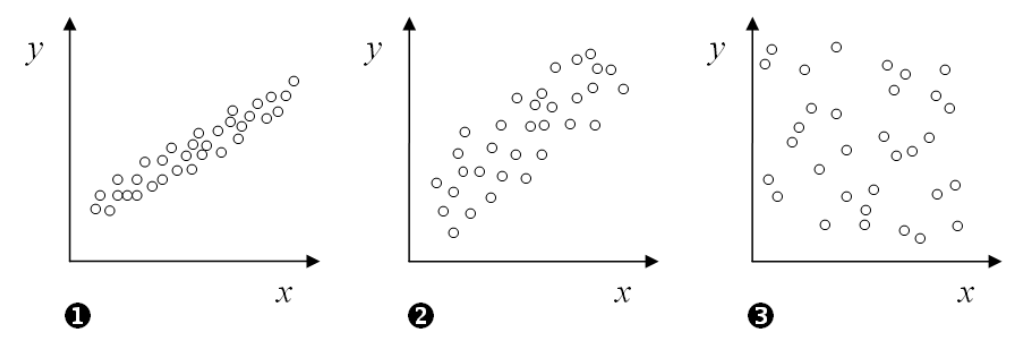

licensed under CC BY-ND 2.0

Nosso objetivo é analisar duas qualidades, desdes pontos:

- Ruido;
- Redundância;

O ruído provem de possíveis fatores  aleatórios levando em erros na medida de um experimento, são assumidos distribuídos normalmente. Graficamente representam direções de pouca variança.

Redundância se refere a se refere à capacidade de predição de uma varável em termos de outras variáveis, se uma determinada varável pode-ser predita com algum nível de acuracidade das medidas de outra variável dizemos que ela é redundante.  


Como nosso objetivo, é projetar nas direções que contenham a maior informação possível, queremos escolher aquelas nas quais os dados variem mais, isto nos leva ao conceito de variança. Considere dos conjuntos e dados:

$$X=\{x_1,\ldots,x_n\} \hspace{1cm} e \hspace{1cm}Y=\{y_1,\ldots,y_n\}$$

Denotando a média aritmética de $X$ e $Y$ por $\bar{x}$ e $\bar{y}$ respetivamente, as varianças de $X$ e $Y$ são individualmente definidas como:

$$var(X):=\frac{1}{n} \sum_i (x_i-\bar{x})^2 \hspace{1cm} e \hspace{1cm}var(Y):= \frac{1}{n } \sum_i (y_i-\bar{y})^2$$

A covariança entre $X$ e $Y$, é definida como:

$$cov(X,Y):=\frac{1}{n} \sum_i (x_i-\bar{x})(y_i-\bar{y})$$










Note que na covarianza podemos ter sinal negativo, em particular, se os dois conjuntos de dados tem uma dependência linear, a covariânza tende a ser maior em valor absoluto, sendo possitiva se medidas respetiva nos conjuntos de dados são proporcionais, ou negativa se medidas respetivas no conjunto de dados são inversamente proporcionas.

Sobre a variança e covariança é possível ainda disser:

- $cov(X,Y)=0$ se e somente se não estão relacionados linearmente, ou ainda, dizemos  que $X$ e $Y$ são **não correlacionados**.

- $cov(X,Y)=var(X)=var(Y)$ se $X=Y$.

Voltando na argumentação heurística temos interesse em preservar as direções de maior variança, logo procuramos achar direções nas quais os dados variem o máximo possível.


Colocando isto em termos de nosso problema, as direções coordenadas são representadas por palavras, logo é conveniente transpor a matriz `BoW` para visualizar os conjuntos de dados como as palavras:

$$X:= BoW^{T}$$

A matriz $X$ tem $2206$ linhas e cada linha representa uma palavra, esta representação pode ser escrita matricialmente como:


$$
   \mathbf{X}=
    \begin{bmatrix}
      |&|&&|\\
      \mathbf{p}_1&\mathbf{p}_2&\dots&\mathbf{p}_{2026}\\
      |&|&&|
    \end{bmatrix}=
    \begin{bmatrix}
      p_{11}                & {p_{12}} &\dots  & p_{1\times 22}\\
      {p_{21}} & p_{22}               &\dots  & {p_{2\times 22}}\\
      \vdots               &\vdots               &\ddots &\vdots\\
      p_{2026 \times 1}                & {p_{2026 \times 2}}&\dots  & p_{2026 \times 22}
    \end{bmatrix}
$$

Queremos determinar a covariância entre as direções canônicas, dito de outra forma a covariança entre conjuntos de dados da forma:

$$cov(\mathbf{p}_i,\mathbf{p}_j)=\frac{1}{22}\sum_i^{22} (\mathbf{p}_{ki}-\bar{\mathbf{p}_i})(\mathbf{p}_{kj}-\mathbf{\bar{p}}_j)$$

O que representa a correlação linear entre as palavras $\mathbf{p}_i$ e $\mathbf{p}_j$.






Como estamos interessados em comparar os textos na íntegra isto envolve comparar todas as palavras, precisamos calcular $2026 \times 2206$ cálculos de covarianças, isto é números da forma:

$$cov(\mathbf{p}_i,\mathbf{p}_j), \hspace{1cm} para\hspace{1cm} i,j \in \{0,\ldots , 2025\}$$

O arranjo retangular, de estes números é chamado matriz de covariança, e formalmente definida como:


$$
cov(\mathbf{X})=
\begin{bmatrix}
      cov(\mathbf{p}_1,\mathbf{p}_1) & cov(\mathbf{p}_1,\mathbf{p}_2)& \dots  &cov(\mathbf{p}_1,\mathbf{p}_{2206})\\
      cov(\mathbf{p}_2,\mathbf{p}_1)         & cov(\mathbf{p}_2,\mathbf{p}_2) & \dots  &cov(\mathbf{p}_2,\mathbf{p}_{2206})\\
      \vdots                      &      \vdots                 &\ddots  &\vdots\\
    cov(\mathbf{p}_{2206},\mathbf{p}_{1})       & cov(\mathbf{p}_{2206},\mathbf{p}_2)         &\dots   &cov(\mathbf{p}_{2206},\mathbf{p}_{2206})
\end{bmatrix}
$$

**Observações**: 
- Cada entrada da matrix $cov(\mathbf{X})$ corresponde a correlação entre duas coordenadas do conjunto de pontos  $\mathbf{BoW}$.
- Elementos na diagonal da matriz de covarianza representa a variação dos respetivos eixos de coordenadas.
- Os elementos na diagonal da matriz correspondem à variância de cada coordenada.


#### Desejamos uma matriz diagonal

Lembre que a se uma covariança $cov(\mathbf{p}_i,\mathbf{p}_j) \neq 0$ significa que existe algum grau de dependência linear entre as varáveis, que por sua vez significaria que há alguma redundância nos dados, assim para ter a menor quantidade de informação redundante, é conveniente fazer pequena a covariança, o mais possível, isto é queremos converter a matriz de covariança numa matriz diagonal, isto é uma matriz da forma:



   
$$\mathbf{D}=\begin{bmatrix}
      var(\mathbf{p}_1) &  0 & \ldots  &0\\
      0 & var(\mathbf{p}_2)& \dots  & 0\\
      \vdots                      &      \vdots                 &\ddots  &\vdots\\
      0      & 0 &\dots   & var(\mathbf{p}_{2206})
\end{bmatrix}
$$





Como conseguir esto?

#### Algumas propriedades importantes da covariança.
1. $cov(X)$ é uma matriz simétrica.
2. $cov(X)$ é semidefinida positiva.

---
**Prova da propriedade 2**: $cov(\mathbf{X})$ é semi definida positiva

O segredo da prova é enxergar que:
$$
cov(\mathbf{X})=\frac{1}{n}\sum_i (\mathbf{x}_{i}-\mu)(\mathbf{x}_{i}-\mu)^\top
$$
onde $\mu=\frac{1}{n}\sum_i \mathbf{x}_{i}$

Assim,
$$
\mathbf{u}^\top cov(\mathbf{X})\mathbf{u}\\
=\mathbf{u}^\top\left( \frac{1}{n}\sum_i (\mathbf{x}_{i}-\mu)(\mathbf{x}_{i}-\mu)^\top \right)\mathbf{u}\\
=  \frac{1}{n}\sum_i \mathbf{u}^\top(\mathbf{x}_{i}-\mu)(\mathbf{x}_{i}-\mu)^\top \mathbf{u}\\
=\frac{1}{n}\sum_i \left((\mathbf{x}_{i}-\mu)^\top \mathbf{u}\right)^2\geq 0
$$

---

#### <font color='blue'> Teorema Espectral</font>

Se $\mathbf{A}$ é matriz simétrica, então:
$$
\mathbf{A}=\mathbf{UDU}^\top \rightarrow \mathbf{U}^\top\mathbf{AU}=\mathbf{D}
$$
onde $\mathbf{U}$ é matriz ortogonal contendo os autovetores de $\mathbf{A}$ e $\mathbf{D}$ é matriz diagonal contendo os autovalores reais de $\mathbf{A}$

---

Temos duas propriedades, da variança e covariança:

- $var(\mathbf{p}_i+b)=Var(\mathbf{p}_i)$ para todo $b \in \mathbb{R}$ e todo $i,j \in \{0, \ldots, 2025\}$;
- $cov(\mathbf{p}_i-b,\mathbf{p}_j-d)= Cov(\mathbf{p}_i,\mathbf{p}_j)$ para todo $b,d \in \mathbb{R}$ e todo $i,j \in \{0, \ldots, 2025\}$.

Estas duas propriedades nos permitem assumir que os conjuntos de dados são de média zero, e em particular calcular a covarianza pela fórmula simplificada:

$$cov(\mathbf{p}_i,\mathbf{p}_j)= \frac{1}{22} \mathbf{p}_i ⋅ \mathbf{p}_j^\top,$$

 e de forma geral

 $$Cov(X)=\frac{1}{n}XX^{T}$$


$\mathbf{XX}^\top$ é uma matriz simétrica esemi-definida positiva. Logo, os autovalores $\lambda _i$ são reais e não negativos. Armazenando os autovetores de $\mathbf{XX}^\top$,pelo teorema espectral existe uma matriz ortonormal formada pelos autovetores de $\mathbf{XX}^\top$ satisfazendo:

$$\mathbf{U}^\top\mathbf{X}\mathbf{X}^\top\mathbf{U} = \mathbf{D}$$

$$
\mathbf{D}=
\begin{bmatrix}
cov(y_{1:},y_{1:}) & 0 & \ldots & 0 \\
0 & cov(y_{2:},y_{2:}) & \ldots & 0 \\
  &            & \vdots & \\
0 & 0 & \ldots & cov(y_{d:},y_{d:}) \\
\end{bmatrix}
$$

**Importante**: $cov(y_{i:},y_{i:}) = \lambda_i$, ou seja, os autovalores de $\mathbf{XX}^\top$ correspondem as variâncias das coordenadas na nova base. Os autovetores de $\mathbf{XX}^\top$ são os elementos da nova base, sendo que coordenadas distintas dos dados nesta nova base são "descorrelacionadas".

As coordenadas dos pontos no novo sistema de coordenadas são dados por:
$$
\mathbf{y_i}=\mathbf{U}^\top\mathbf{\mathbf{p}_i}
$$

---
#### <font color='blue'>Quociente de Rayleigh</font>
    
Assumindo que os autovalores estão ordenados $\lambda_1\geq\cdots\geq\lambda_d$, o _Quociente de Rayleigh_ assegura:

$$
\mathbf{u}_1^\top\mathbf{XX}^\top\mathbf{u}_1=\lambda_1 \rightarrow \mathbf{u}_1 \mbox{ (direção de maior variância)}\\
\mathbf{u}_d^\top\mathbf{XX}^\top\mathbf{u}_d=\lambda_d \rightarrow \mathbf{u}_d \mbox{ (direção de menor variância)}
$$


---

De esta forma, podemos  estar interessados únicamente nas direções **coordenadas** de maior variança, e despreciar aquelas que se correspondem com ruido.

#### <font color='blue'>Variança acumulada pelas direções principais</font>

Como visto acima, as direções **coordenadas** com variância próximas de zero podem ser desconsideradas, por corresponder a ruído dos dados. 

Por outro lado depois de ordenar os autovalores, sabemos que as direções novas $\mathbf{y}_i= U^\top \mathbf{p}_i$ capturam as direções de maior variança


  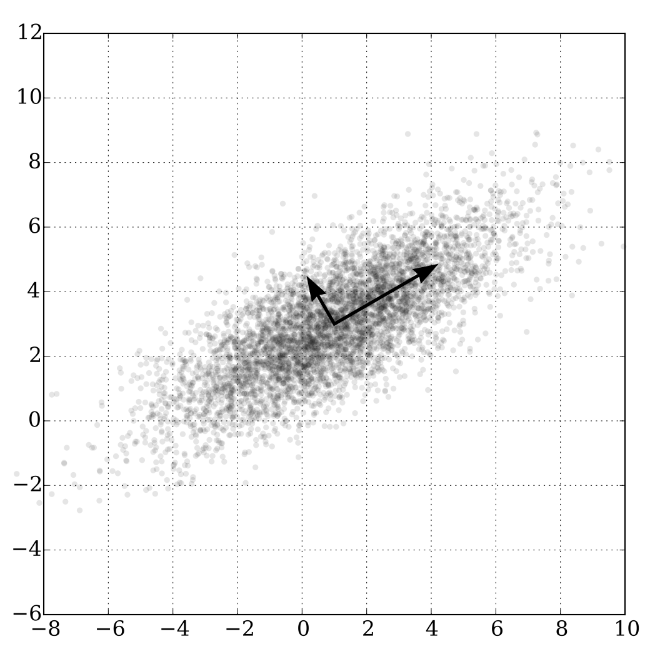

GaussianScatterPCA available at [link](https://creativecommons.org/use-remix/attribution/) is licensed under CC BY-ND 2.0



Podemos medir a "quantidade de informação" capturada por cada direção através da chamada _proporção de variância explicada_, que matemáticamente é dada por:

$$
\frac{\lambda_i}{\lambda_1+\cdots+\lambda_d}
$$

Para cada $i$, o valor acima mede a proporção da variância capturada por cada direção principal. Desta forma, se quisermos encontrar quantas direções são necessárias para
capturar 90% da variância, basta encontrarmos o menor $k$ tal que:

$$
\frac{1}{\lambda_1+\cdots+\lambda_d}\sum_{i=1}^k \lambda_i \geq 0.9
$$

### Implementção do PCA para visualização de textos em $\mathbb{R}^2$

Etiquetamos todos os textos, segundo o canal de precedencia, isto não influenciara na implementação de PCA, mas é feito unicamente para ajudar na visualização:

In [78]:


docid = {}
for i,c in enumerate(BoW.index.values):
   if c[0:2] not in docid:              # as duas letras iniciais do indice indicam o
      docid[c[0:2]] = i                 # tópico ao qual o documento está relacionado
                                        # docid armazena como chave o tópico e valor 
print(docid)                            # a linha onde aparece pela primeira vez 
        
doc_ids = [docid[c[0:2]] for c in BoW.index.values] # cria uma lista de labels indicando
                                                    # a qual topico o documento pertence.  
                                                    # Os labels serão utilizados para colorir
                                                    # os documentos de acordo com seu tópico
print(doc_ids)

{'ND': 0, 'CT': 1}
[0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0]


In [79]:
from sklearn.decomposition import PCA  #submetodo 
from sklearn.preprocessing import StandardScaler

X = BoW.values
X = StandardScaler().fit_transform(X)       # Aplica uma normalização Z-score
                                    # nos dados para melhorar o resultado do PCA
                                                   


[262.30206525 250.54466995 162.87681226 129.10605029 121.95251851
 119.80522725 109.63046729 106.58089859 105.25588411  99.55462033]

  [0.1134992  0.22191093 0.29238841 0.34825314 0.40102251 0.45286273
 0.5003003  0.5464183  0.59196296 0.63504066]


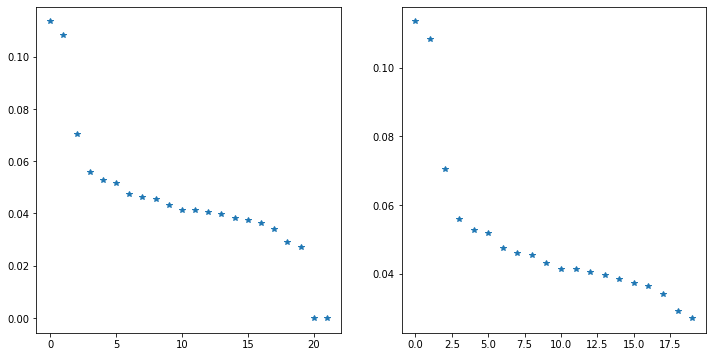

In [87]:
data_pca=PCA(svd_solver='full')
#full oara calcular todas as componentes
data_transformed = data_pca.fit(X)
#aplicando a transformação

print(data_transformed.explained_variance_[:10])
print('\n ',data_transformed.explained_variance_ratio_.cumsum()[:10])

plt.rcParams['figure.figsize'] = [12, 6]
f, (ax1, ax2)  = plt.subplots(1,2)

ax1.plot(data_pca.explained_variance_ratio_, '*') 
ax2.plot(data_pca.explained_variance_ratio_[:20], '*') 



In [81]:

pca_obj = PCA(n_components=2)
Xpca = pca_obj.fit_transform(X)  # projeta os dados originais nas duas componentes principais

print(Xpca.shape)
#Xpca
#BoW.to_csv('bag_of_words_4.csv')

(22, 2)


[0 1]


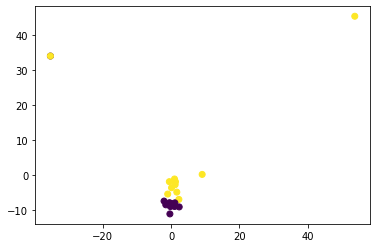

In [82]:
import matplotlib.pyplot as plt
%matplotlib inline

print(np.unique(doc_ids))
plt.scatter(Xpca[:,0],Xpca[:,1],c=doc_ids)

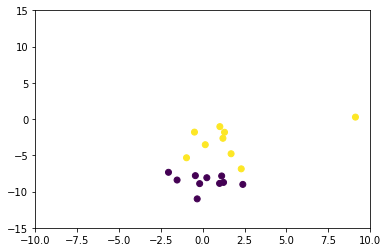

In [83]:
fig, ax = plt.subplots()
ax.set_xlim(-10, 10)
ax.set_ylim(-15, 15)

plt.scatter(Xpca[:,0],Xpca[:,1],c=doc_ids)

    
## Bibliografia
- [nltk book](https://www.nltk.org/book/)
- [Principal Component Analysis,
H. Abdi, L.J. Williams](https://wwwpub.utdallas.edu/~herve/abdi-wireCS-PCA2010-inpress.pdf)